# NeuroTrace
**U-Net Brain Tumor Segmentation** — CS 571

Predicts pixel-level tumor masks from LGG brain MRI images using a U-Net trained with combined BCE + Dice loss.

Run cells top to bottom. Make sure the Colab runtime is set to **GPU** (Runtime → Change runtime type → T4 GPU).

## 1. Install dependencies

In [1]:
!pip install -q albumentations opencv-python-headless tqdm scikit-learn

## 2. Upload / mount the dataset

Download **LGG Brain MRI Segmentation** from Kaggle:  
https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation

Then either:
- **Option A** — Mount Google Drive and point `DATA_DIR` at the extracted folder, or  
- **Option B** — Upload the zip directly and unzip it here.

In [2]:
import os, glob, zipfile

ZIP_PATH = '/content/archive (1).zip'
EXTRACT_TO = '/content/dataset/'

print("Extracting... (this may take a minute)")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)
print("Done.")

# Find the kaggle_3m folder wherever it landed
matches = glob.glob(f'{EXTRACT_TO}**/kaggle_3m', recursive=True)
if not matches:
    contents = os.listdir(EXTRACT_TO)
    raise FileNotFoundError(f'kaggle_3m not found. Top-level contents: {contents}')

DATA_DIR = matches[0]
print(f'DATA_DIR = {DATA_DIR}')

Extracting... (this may take a minute)
Done.
DATA_DIR = /content/dataset/kaggle_3m


## 3. Clone / upload the project files

If you pushed this repo to GitHub, clone it. Otherwise upload `data.py`, `model.py`, `train.py`, and `eval.py` manually.

In [3]:
# Clone from GitHub (replace with your repo URL)
# !git clone https://github.com/<your-username>/NeuroTrace.git
# %cd NeuroTrace

# Or just verify the files are present in the current directory
import os
for f in ['data.py', 'model.py', 'train.py', 'eval.py']:
    status = '✓' if os.path.exists(f) else '✗  MISSING'
    print(f"{status}  {f}")

✓  data.py
✓  model.py
✓  train.py
✓  eval.py


## 4. Imports & device

In [4]:
import torch
from data  import build_dataloaders
from model import UNet, count_parameters
from train import train
from eval  import evaluate, visualize_predictions, plot_training_history

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 5. Hyperparameters

In [5]:
IMAGE_SIZE   = 256
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-5
CHECKPOINT   = 'best_model.pth'

## 6. Build dataloaders

In [6]:
train_loader, val_loader, test_loader = build_dataloaders(
    DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Dataset split — train: 2749  val: 590  test: 590


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 7. Visualize a sample batch

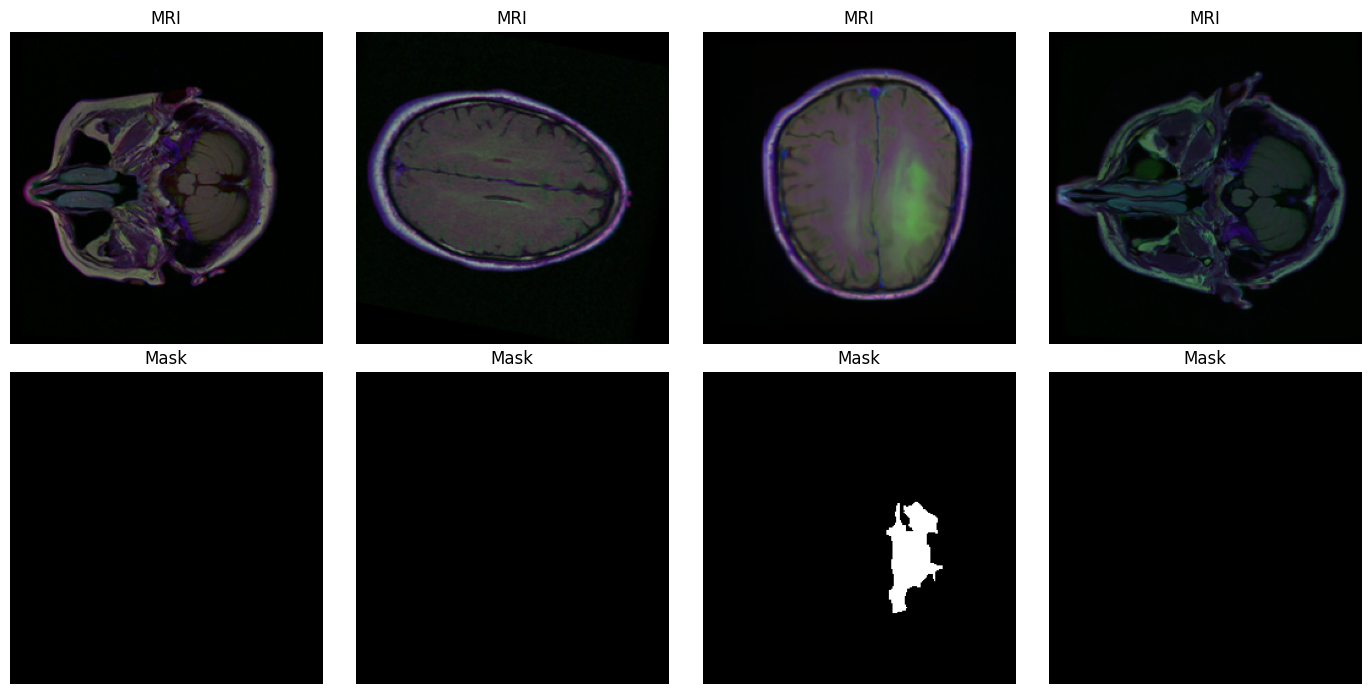

In [7]:
import matplotlib.pyplot as plt
import numpy as np

images, masks = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    img = images[i].numpy().transpose(1, 2, 0)
    img = np.clip(std * img + mean, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title('MRI')
    axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Mask')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 8. Build the U-Net model

In [8]:
model = UNet(in_channels=3, out_channels=1)
count_parameters(model)

Total parameters:     31,037,633
Trainable parameters: 31,037,633


31037633

## 9. Train

In [9]:
history = train(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    checkpoint_path=CHECKPOINT,
    device=DEVICE,
    use_amp=True,
)

Training on cuda  |  epochs: 30  |  lr: 0.0001
-------------------------------------------------------


Epoch 001/30  train_loss: 0.6692  train_dice: 0.4103  val_loss: 0.6170  val_dice: 0.5759
  ✓ Saved best model (val_dice=0.5759)


Epoch 002/30  train_loss: 0.6002  train_dice: 0.5946  val_loss: 0.5822  val_dice: 0.6412
  ✓ Saved best model (val_dice=0.6412)


Epoch 003/30  train_loss: 0.5724  train_dice: 0.6314  val_loss: 0.5580  val_dice: 0.7009
  ✓ Saved best model (val_dice=0.7009)


Epoch 004/30  train_loss: 0.5509  train_dice: 0.6148  val_loss: 0.5359  val_dice: 0.6541


...

Epoch 026/30  train_loss: 0.1229  train_dice: 0.8394  val_loss: 0.1088  val_dice: 0.8615


Epoch 027/30  train_loss: 0.1171  train_dice: 0.8466  val_loss: 0.1071  val_dice: 0.8656
  ✓ Saved best model (val_dice=0.8656)


Epoch 028/30  train_loss: 0.1163  train_dice: 0.8456  val_loss: 0.1047  val_dice: 0.8638


Epoch 029/30  train_loss: 0.1122  train_dice: 0.8485  val_loss: 0.1041  val_dice: 0.8650


Epoch 030/30  train_loss: 0.1082  train_dice: 0.8521  val_loss: 0.1013  val_dice: 0.8641
-------------------------------------------------------
Training complete. Best val Dice: 0.8656


## 10. Plot training curves

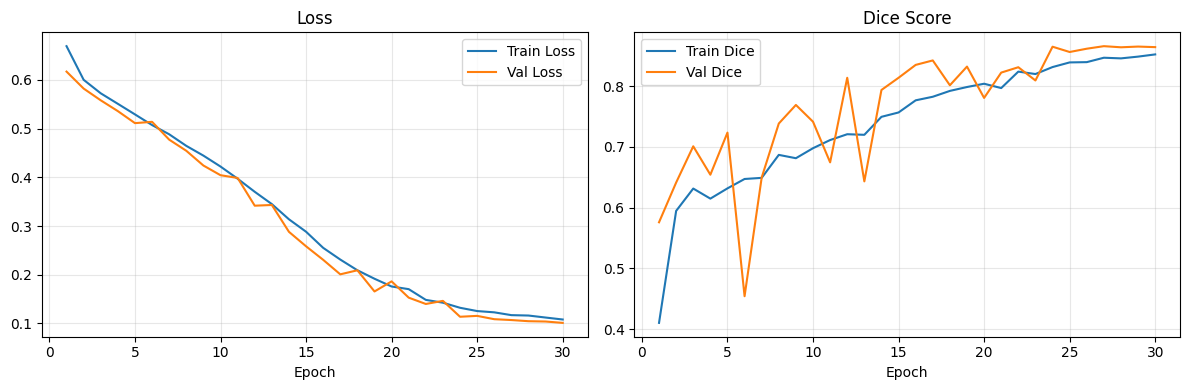

In [10]:
plot_training_history(history)

## 11. Evaluate on the test set

In [11]:
# Load the best checkpoint before evaluating
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))

results = evaluate(model, test_loader, DEVICE)

Evaluating: 100%|██████████| 19/19 [00:09<00:00,  1.98it/s]

Test Dice: 0.8472  |  Test IoU: 0.7376


## 12. Visualize predictions

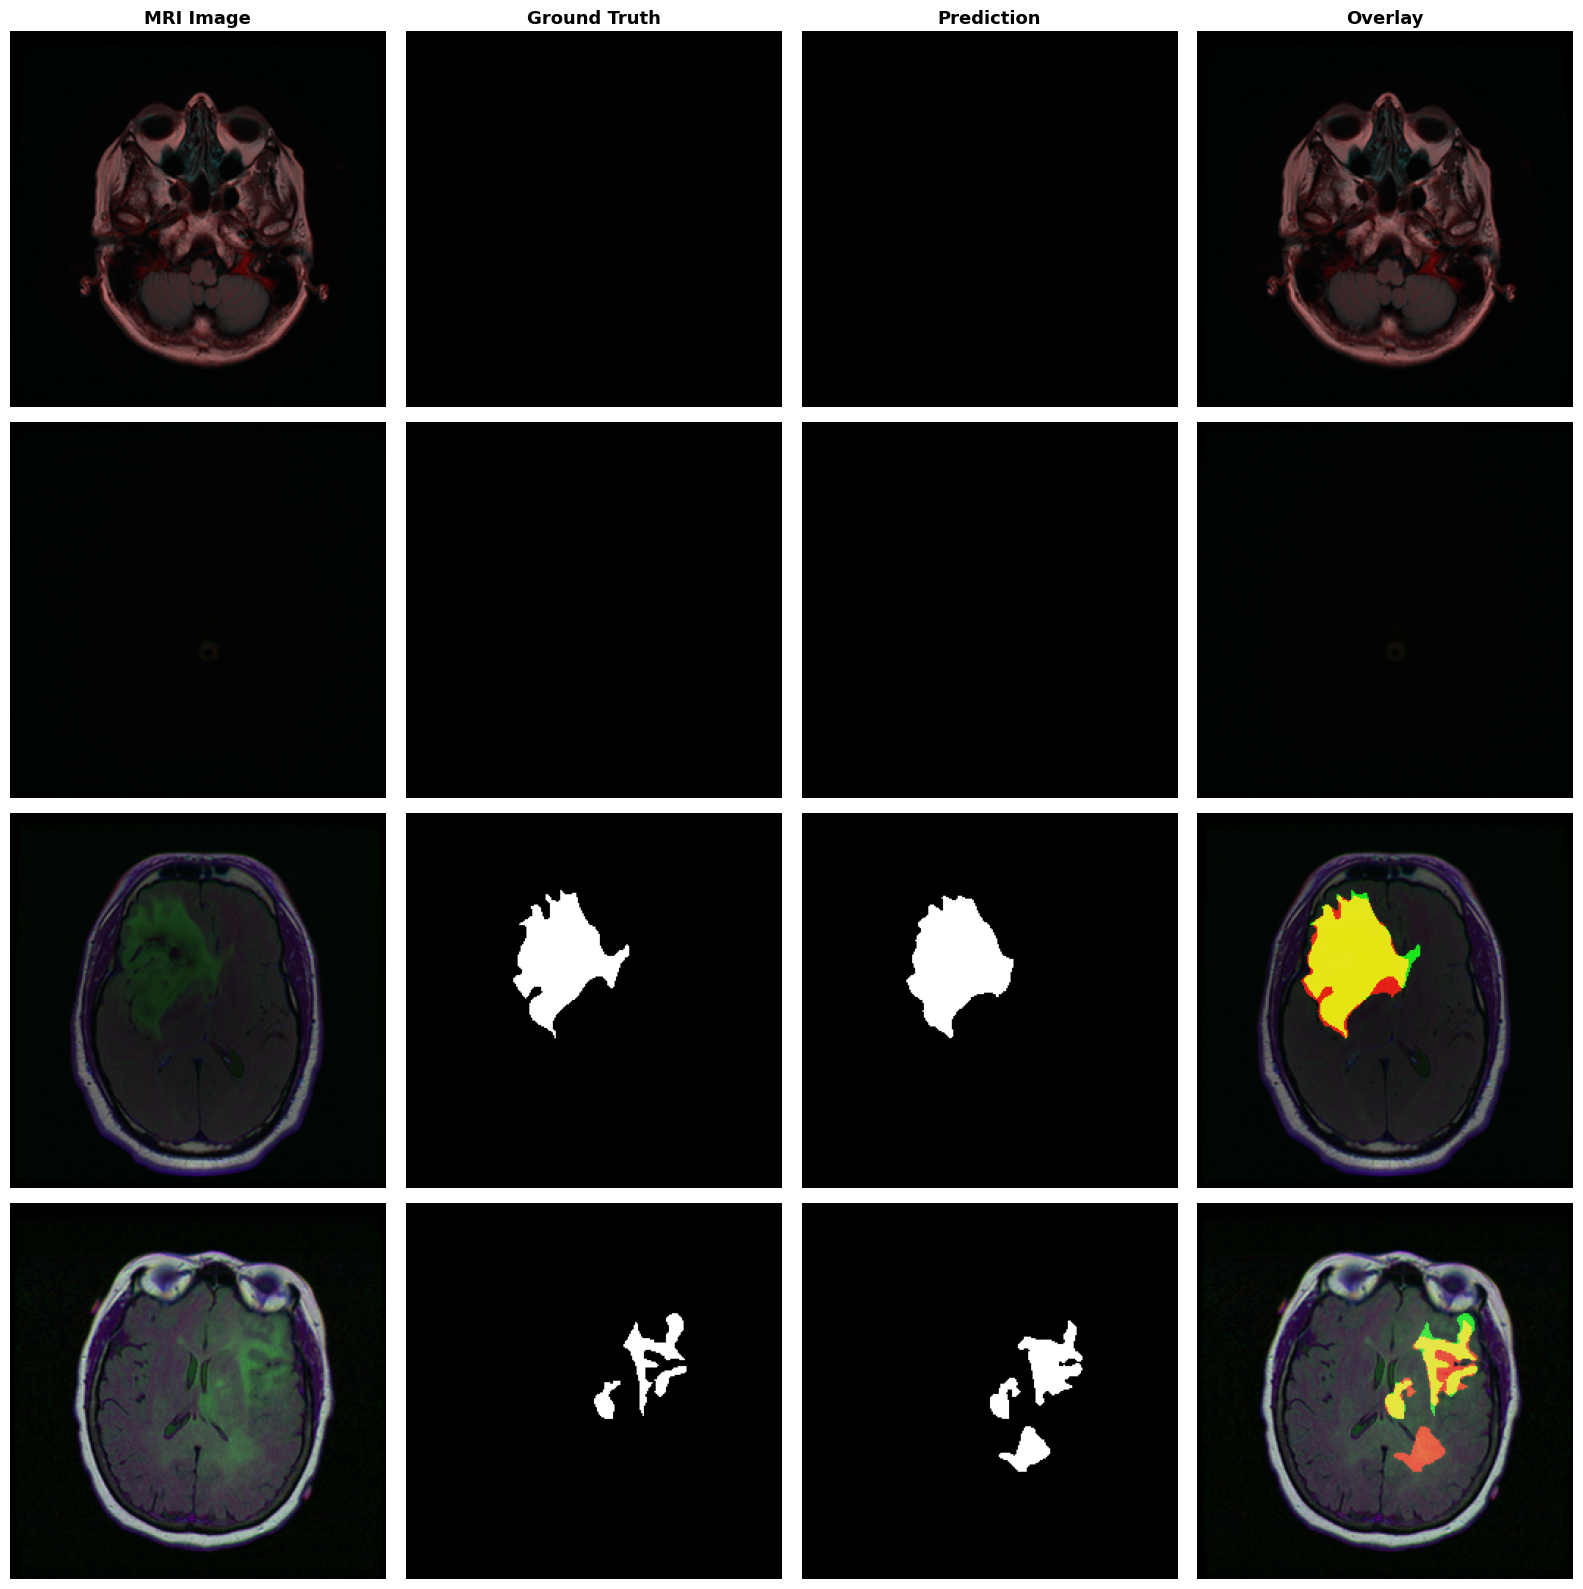

In [12]:
visualize_predictions(model, test_loader, DEVICE, n_samples=4)